# Part 2f: Custom Optimizers in Deep Learning

## Overview

In this notebook, we'll explore how to create **custom optimizers** in both TensorFlow/Keras and PyTorch. Understanding and implementing custom optimizers gives you deeper insight into gradient-based optimization and allows you to experiment with novel optimization algorithms.

### Topics Covered:
1. **Understanding Optimizers** - How optimization works in deep learning
2. **Custom Momentum Optimizer** - Implementing momentum from scratch
3. **Custom Adam Optimizer** - Implementing Adam algorithm
4. **Custom SGD with Warm Restarts** - Implementing SGDR
5. **Comparison and Visualization** - Comparing optimizer behaviors

### Why Custom Optimizers?
- Implement novel optimization algorithms from research papers
- Fine-tune optimization behavior for specific problems
- Deep understanding of gradient-based learning

In [1]:
# Install required packages (for Google Colab)
!pip install -q tensorflow torch matplotlib seaborn

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Optimizer
from torch.utils.data import DataLoader, TensorDataset

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")

TensorFlow version: 2.19.0
PyTorch version: 2.10.0+cu128


---

## 1. Understanding Optimizers

### Gradient Descent Update Rule

The basic gradient descent update is:

$$\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$$

where:
- $\theta$ are the model parameters
- $\eta$ is the learning rate
- $\nabla L$ is the gradient of the loss

### Common Optimizers

| Optimizer | Key Feature | Update Rule |
|-----------|-------------|-------------|
| SGD | Basic gradient descent | $\theta = \theta - \eta g$ |
| Momentum | Accumulates past gradients | $v = \beta v + g; \theta = \theta - \eta v$ |
| RMSprop | Adaptive learning rates | Uses running average of squared gradients |
| Adam | Momentum + RMSprop | Combines first and second moment estimates |

---

## 2. Custom Momentum Optimizer

### Mathematical Definition:

$$v_t = \beta v_{t-1} + \nabla L(\theta_t)$$
$$\theta_{t+1} = \theta_t - \eta v_t$$

where $\beta$ is the momentum coefficient (typically 0.9).

### 2.1 TensorFlow/Keras Implementation

In [3]:
class MyMomentumOptimizer(keras.optimizers.Optimizer):
    """
    Custom Momentum Optimizer implementation.

    Implements SGD with momentum for accelerated convergence.

    Parameters:
    -----------
    learning_rate : float
        Step size for parameter updates
    momentum : float
        Momentum coefficient (0-1), typically 0.9
    nesterov : bool
        Whether to use Nesterov momentum
    """

    def __init__(self, learning_rate=0.01, momentum=0.9, nesterov=False,
                 name='MyMomentumOptimizer', **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self._momentum = momentum
        self._nesterov = nesterov

    def build(self, var_list):
        """Initialize optimizer state (velocity for each variable)."""
        super().build(var_list)
        if hasattr(self, '_built') and self._built:
            return

        # Create velocity variables for each trainable variable
        self._velocities = []
        for var in var_list:
            self._velocities.append(
                self.add_variable_from_reference(
                    reference_variable=var, name='velocity'
                )
            )
        self._built = True

    def update_step(self, gradient, variable, learning_rate):
        """Perform a single optimization step."""
        # Get the velocity for this variable
        var_key = self._get_variable_index(variable)
        velocity = self._velocities[var_key]

        # Get hyperparameters
        lr = tf.cast(learning_rate, variable.dtype)
        momentum = tf.cast(self._momentum, variable.dtype)

        # Update velocity: v = momentum * v + gradient
        velocity.assign(momentum * velocity + gradient)

        if self._nesterov:
            # Nesterov momentum: look ahead
            variable.assign_sub(lr * (gradient + momentum * velocity))
        else:
            # Standard momentum
            variable.assign_sub(lr * velocity)

    def _get_variable_index(self, variable):
        """Get index of variable in the velocity list."""
        for i, var in enumerate(self._trainable_variables):
            if var is variable:
                return i
        raise ValueError(f"Variable {variable.name} not found")

    def get_config(self):
        config = super().get_config()
        config.update({
            'momentum': self._momentum,
            'nesterov': self._nesterov
        })
        return config

In [4]:
# Simple implementation - let Keras handle variable indexing
class MyMomentumOptimizerSimple(keras.optimizers.Optimizer):
    """
    Simplified Momentum Optimizer for educational purposes.

    Compatible with Keras 3.x using add_variable_from_reference.
    """

    def __init__(self, learning_rate=0.01, momentum=0.9, name='MyMomentumSimple', **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.momentum = momentum

    def build(self, var_list):
        if hasattr(self, '_built') and self._built:
            return
        super().build(var_list)

        # Create velocity variables using Keras' internal mechanism
        self._velocities = []
        for var in var_list:
            self._velocities.append(
                self.add_variable_from_reference(var, name='velocity')
            )
        self._built = True

    def update_step(self, gradient, variable, learning_rate):
        # Access velocity by index - Keras processes variables in consistent order
        # Get index by finding position in the internally tracked variables
        try:
            # Try using Keras internal index dict if available
            idx = self._index_dict[self._var_key(variable)]
        except (AttributeError, KeyError):
            # Fallback: search by variable path
            var_path = variable.path if hasattr(variable, 'path') else variable.name
            idx = None
            for i, v in enumerate(self._trainable_variables):
                v_path = v.path if hasattr(v, 'path') else v.name
                if v_path == var_path:
                    idx = i
                    break
            if idx is None:
                # Last fallback: use iteration order (assumes consistent ordering)
                if not hasattr(self, '_call_count'):
                    self._call_count = 0
                idx = self._call_count % len(self._velocities)
                self._call_count += 1

        velocity = self._velocities[idx]

        # v = momentum * v + gradient
        velocity.assign(self.momentum * velocity + gradient)

        # theta = theta - lr * v
        variable.assign_sub(learning_rate * velocity)

    def get_config(self):
        config = super().get_config()
        config['momentum'] = self.momentum
        return config

In [5]:
# Test custom momentum optimizer
print("Testing TensorFlow Custom Momentum Optimizer:")
print("=" * 50)

# Create simple test data
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = X_train.reshape(-1, 784)[:5000]  # Use subset
X_test = X_test.reshape(-1, 784)[:1000]
y_train = y_train[:5000]
y_test = y_test[:1000]

# Build model
def create_model():
    return keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

# Train with custom optimizer
model_custom = create_model()
model_custom.compile(
    optimizer=MyMomentumOptimizerSimple(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_custom = model_custom.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    verbose=1
)

Testing TensorFlow Custom Momentum Optimizer:
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6490 - loss: 1.2188 - val_accuracy: 0.8360 - val_loss: 0.5671
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8892 - loss: 0.3905 - val_accuracy: 0.8820 - val_loss: 0.4171
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9160 - loss: 0.3029 - val_accuracy: 0.8890 - val_loss: 0.3798
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9268 - loss: 0.2585 - val_accuracy: 0.8900 - val_loss: 0.3552
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9372 - loss: 0.2269 - val_accuracy: 0.9040 - val_loss: 0.3321
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9456 - loss: 0.2003 - val_accuracy: 0.9100 - val_loss: 0.3157
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9526 - loss: 0.1761 - val_accuracy: 0.9110 - val_loss: 0.3119
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9580 - loss: 0.1548 - val_accuracy: 0.9080 - val_loss

In [6]:
# Compare with built-in SGD with momentum
model_builtin = create_model()
model_builtin.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_builtin = model_builtin.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6224 - loss: 1.3006 - val_accuracy: 0.8200 - val_loss: 0.5800
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8846 - loss: 0.4108 - val_accuracy: 0.8790 - val_loss: 0.4242
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9134 - loss: 0.3098 - val_accuracy: 0.8850 - val_loss: 0.3821
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9274 - loss: 0.2603 - val_accuracy: 0.8890 - val_loss: 0.3568
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9360 - loss: 0.2264 - val_accuracy: 0.8890 - val_loss: 0.3427
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9436 - loss: 0.2005 - val_accuracy: 0.8930 - val_loss: 0.3265
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9510 - loss: 0.1776 - val_accuracy: 0.8940 - val_loss: 0.3131
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9574 - loss: 0.1569 - val_accuracy: 0.9040 - val_loss

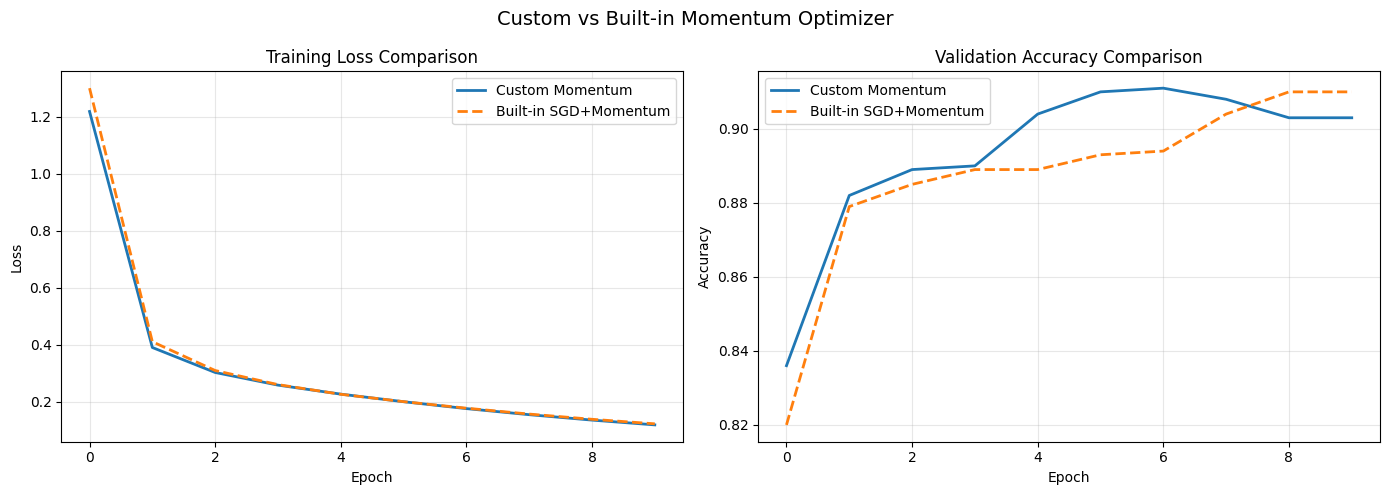

In [7]:
# Compare results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(history_custom.history['loss'], label='Custom Momentum', linewidth=2)
axes[0].plot(history_builtin.history['loss'], '--', label='Built-in SGD+Momentum', linewidth=2)
axes[0].set_title('Training Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(history_custom.history['val_accuracy'], label='Custom Momentum', linewidth=2)
axes[1].plot(history_builtin.history['val_accuracy'], '--', label='Built-in SGD+Momentum', linewidth=2)
axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Custom vs Built-in Momentum Optimizer', fontsize=14)
plt.tight_layout()
plt.show()

### 2.2 PyTorch Implementation

In [8]:
class MyMomentumOptimizerPyTorch(Optimizer):
    """
    Custom Momentum Optimizer for PyTorch.

    Parameters:
    -----------
    params : iterable
        Model parameters
    lr : float
        Learning rate
    momentum : float
        Momentum coefficient
    nesterov : bool
        Use Nesterov momentum
    """

    def __init__(self, params, lr=0.01, momentum=0.9, nesterov=False):
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if momentum < 0.0:
            raise ValueError(f"Invalid momentum value: {momentum}")

        defaults = dict(lr=lr, momentum=momentum, nesterov=nesterov)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        """
        Perform a single optimization step.

        Parameters:
        -----------
        closure : callable, optional
            A closure that reevaluates the model and returns the loss
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            momentum = group['momentum']
            nesterov = group['nesterov']
            lr = group['lr']

            for p in group['params']:
                if p.grad is None:
                    continue

                d_p = p.grad.data

                # Get or initialize velocity
                param_state = self.state[p]
                if 'velocity' not in param_state:
                    param_state['velocity'] = torch.zeros_like(p.data)

                velocity = param_state['velocity']

                # Update velocity: v = momentum * v + gradient
                velocity.mul_(momentum).add_(d_p)

                if nesterov:
                    # Nesterov: look ahead
                    p.data.add_(d_p + momentum * velocity, alpha=-lr)
                else:
                    # Standard momentum
                    p.data.add_(velocity, alpha=-lr)

        return loss

In [9]:
# Test PyTorch custom momentum optimizer
print("Testing PyTorch Custom Momentum Optimizer:")
print("=" * 50)

# Convert data
X_train_pt = torch.tensor(X_train, dtype=torch.float32)
y_train_pt = torch.tensor(y_train, dtype=torch.long)
X_test_pt = torch.tensor(X_test, dtype=torch.float32)
y_test_pt = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_pt, y_train_pt)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# PyTorch model
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# Train with custom optimizer
model_pt_custom = SimpleNet()
optimizer_custom = MyMomentumOptimizerPyTorch(model_pt_custom.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()

history_pt_custom = {'loss': [], 'accuracy': []}

for epoch in range(10):
    model_pt_custom.train()
    total_loss = 0.0
    correct = 0

    for X_batch, y_batch in train_loader:
        optimizer_custom.zero_grad()
        outputs = model_pt_custom(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer_custom.step()

        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()

    # Validation
    model_pt_custom.eval()
    with torch.no_grad():
        val_outputs = model_pt_custom(X_test_pt)
        val_acc = (val_outputs.argmax(dim=1) == y_test_pt).float().mean().item()

    history_pt_custom['loss'].append(total_loss / len(train_loader))
    history_pt_custom['accuracy'].append(val_acc)

    print(f"Epoch {epoch+1}: Loss={total_loss/len(train_loader):.4f}, Val Acc={val_acc:.4f}")

Testing PyTorch Custom Momentum Optimizer:
Epoch 1: Loss=2.0747, Val Acc=0.5440
Epoch 2: Loss=0.8482, Val Acc=0.7980
Epoch 3: Loss=0.4648, Val Acc=0.8630
Epoch 4: Loss=0.3746, Val Acc=0.8780
Epoch 5: Loss=0.3042, Val Acc=0.8800
Epoch 6: Loss=0.2787, Val Acc=0.8860
Epoch 7: Loss=0.2519, Val Acc=0.8910
Epoch 8: Loss=0.2255, Val Acc=0.9000
Epoch 9: Loss=0.2046, Val Acc=0.8940
Epoch 10: Loss=0.1807, Val Acc=0.9080


---

## 3. Custom Adam Optimizer

Adam combines momentum with adaptive learning rates.

### Mathematical Definition:

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
$$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$$
$$\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$
$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

In [10]:
class MyAdamOptimizer(keras.optimizers.Optimizer):
    """
    Custom Adam Optimizer compatible with Keras 3.x.
    """

    def __init__(self, learning_rate=0.001, beta_1=0.9, beta_2=0.999,
                 epsilon=1e-7, name='MyAdam', **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        self.epsilon = epsilon

    def build(self, var_list):
        if hasattr(self, '_built') and self._built:
            return
        super().build(var_list)
        self._m_list = []
        self._v_list = []
        for var in var_list:
            self._m_list.append(self.add_variable_from_reference(var, name='m'))
            self._v_list.append(self.add_variable_from_reference(var, name='v'))
        self._built = True

    def _get_var_index(self, variable):
        try:
            return self._index_dict[self._var_key(variable)]
        except (AttributeError, KeyError):
            var_path = variable.path if hasattr(variable, 'path') else variable.name
            for i, v in enumerate(self._trainable_variables):
                v_path = v.path if hasattr(v, 'path') else v.name
                if v_path == var_path:
                    return i
            if not hasattr(self, '_call_count'):
                self._call_count = 0
            idx = self._call_count % len(self._m_list)
            self._call_count += 1
            return idx

    def update_step(self, gradient, variable, learning_rate):
        idx = self._get_var_index(variable)
        m = self._m_list[idx]
        v = self._v_list[idx]

        local_step = tf.cast(self.iterations + 1, variable.dtype)
        lr = tf.cast(learning_rate, variable.dtype)
        beta_1 = tf.cast(self.beta_1, variable.dtype)
        beta_2 = tf.cast(self.beta_2, variable.dtype)
        epsilon = tf.cast(self.epsilon, variable.dtype)

        m.assign(beta_1 * m + (1 - beta_1) * gradient)
        v.assign(beta_2 * v + (1 - beta_2) * tf.square(gradient))

        m_hat = m / (1 - tf.pow(beta_1, local_step))
        v_hat = v / (1 - tf.pow(beta_2, local_step))

        variable.assign_sub(lr * m_hat / (tf.sqrt(v_hat) + epsilon))

    def get_config(self):
        config = super().get_config()
        config.update({
            'beta_1': self.beta_1,
            'beta_2': self.beta_2,
            'epsilon': self.epsilon
        })
        return config

In [11]:
# PyTorch Adam implementation
class MyAdamOptimizerPyTorch(Optimizer):
    """
    Custom Adam Optimizer for PyTorch.
    """

    def __init__(self, params, lr=0.001, betas=(0.9, 0.999), eps=1e-8):
        defaults = dict(lr=lr, betas=betas, eps=eps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            beta1, beta2 = group['betas']
            lr = group['lr']
            eps = group['eps']

            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.data

                # Initialize state
                state = self.state[p]
                if len(state) == 0:
                    state['step'] = 0
                    state['m'] = torch.zeros_like(p.data)
                    state['v'] = torch.zeros_like(p.data)

                m, v = state['m'], state['v']
                state['step'] += 1
                step = state['step']

                # Update biased first moment
                m.mul_(beta1).add_(grad, alpha=1 - beta1)

                # Update biased second moment
                v.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                # Bias correction
                m_hat = m / (1 - beta1 ** step)
                v_hat = v / (1 - beta2 ** step)

                # Update parameters
                p.data.addcdiv_(m_hat, v_hat.sqrt().add_(eps), value=-lr)

        return loss

In [12]:
# Test custom Adam
print("Testing Custom Adam Optimizer:")
print("=" * 50)

# TensorFlow test
model_adam_custom = create_model()
model_adam_custom.compile(
    optimizer=MyAdamOptimizer(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_adam_custom = model_adam_custom.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    verbose=1
)

Testing Custom Adam Optimizer:
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7548 - loss: 0.8780 - val_accuracy: 0.8630 - val_loss: 0.4530
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9160 - loss: 0.3031 - val_accuracy: 0.8980 - val_loss: 0.3436
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9360 - loss: 0.2229 - val_accuracy: 0.9030 - val_loss: 0.3081
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9520 - loss: 0.1724 - val_accuracy: 0.9160 - val_loss: 0.2753
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9650 - loss: 0.1321 - val_accuracy: 0.9180 - val_loss: 0.2575
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9736 - loss: 0.1025 - val_accuracy: 0.9120 - val_loss: 0.2638
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9820 - loss: 0.0783 - val_accuracy: 0.9140 - val_loss: 0.2690
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9874 - loss: 0.0592 - val_accuracy: 0.9200 - val_loss: 0.2561
Ep

In [13]:
# Compare with built-in Adam
model_adam_builtin = create_model()
model_adam_builtin.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_adam_builtin = model_adam_builtin.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7602 - loss: 0.8941 - val_accuracy: 0.8610 - val_loss: 0.4430
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9166 - loss: 0.2999 - val_accuracy: 0.9010 - val_loss: 0.3367
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9420 - loss: 0.2150 - val_accuracy: 0.9160 - val_loss: 0.2983
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9574 - loss: 0.1662 - val_accuracy: 0.9150 - val_loss: 0.2743
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9656 - loss: 0.1304 - val_accuracy: 0.9170 - val_loss: 0.2504
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9746 - loss: 0.1024 - val_accuracy: 0.9200 - val_loss: 0.2369
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9816 - loss: 0.0790 - val_accuracy: 0.9210 - val_loss: 0.2357
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9874 - loss: 0.0608 - val_accuracy: 0.9210 - val_loss

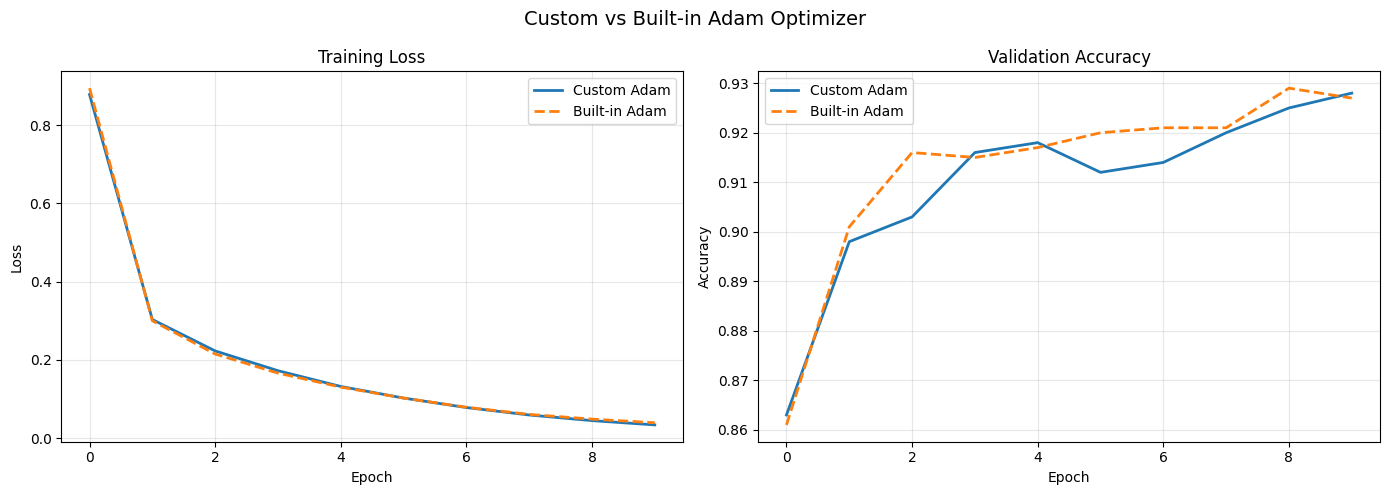

In [14]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
axes[0].plot(history_adam_custom.history['loss'], label='Custom Adam', linewidth=2)
axes[0].plot(history_adam_builtin.history['loss'], '--', label='Built-in Adam', linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation accuracy
axes[1].plot(history_adam_custom.history['val_accuracy'], label='Custom Adam', linewidth=2)
axes[1].plot(history_adam_builtin.history['val_accuracy'], '--', label='Built-in Adam', linewidth=2)
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Custom vs Built-in Adam Optimizer', fontsize=14)
plt.tight_layout()
plt.show()

---

## 4. Custom SGD with Warm Restarts (SGDR)

SGDR uses cosine annealing with warm restarts for the learning rate.

In [15]:
class SGDWarmRestarts(keras.optimizers.Optimizer):
    """
    SGD with Warm Restarts (SGDR) compatible with Keras 3.x.
    """

    def __init__(self, learning_rate=0.1, T_0=10, T_mult=2, eta_min=0.0,
                 momentum=0.9, name='SGDR', **kwargs):
        super().__init__(learning_rate=learning_rate, name=name, **kwargs)
        self.T_0 = T_0
        self.T_mult = T_mult
        self.eta_min = eta_min
        self.momentum = momentum
        self.T_cur = 0
        self.T_i = T_0

    def build(self, var_list):
        if hasattr(self, '_built') and self._built:
            return
        super().build(var_list)
        self._velocities = []
        for var in var_list:
            self._velocities.append(self.add_variable_from_reference(var, name='velocity'))
        self._built = True

    def _get_var_index(self, variable):
        try:
            return self._index_dict[self._var_key(variable)]
        except (AttributeError, KeyError):
            var_path = variable.path if hasattr(variable, 'path') else variable.name
            for i, v in enumerate(self._trainable_variables):
                v_path = v.path if hasattr(v, 'path') else v.name
                if v_path == var_path:
                    return i
            if not hasattr(self, '_call_count'):
                self._call_count = 0
            idx = self._call_count % len(self._velocities)
            self._call_count += 1
            return idx

    def _get_lr(self):
        eta_max = float(self._learning_rate)
        lr = self.eta_min + (eta_max - self.eta_min) * (1 + np.cos(np.pi * self.T_cur / self.T_i)) / 2
        return lr

    def update_step(self, gradient, variable, learning_rate):
        current_lr = tf.cast(self._get_lr(), variable.dtype)
        idx = self._get_var_index(variable)
        velocity = self._velocities[idx]

        velocity.assign(self.momentum * velocity + gradient)
        variable.assign_sub(current_lr * velocity)

    def _update_schedule(self):
        self.T_cur += 1
        if self.T_cur >= self.T_i:
            self.T_cur = 0
            self.T_i = self.T_i * self.T_mult

    def get_config(self):
        config = super().get_config()
        config.update({
            'T_0': self.T_0,
            'T_mult': self.T_mult,
            'eta_min': self.eta_min,
            'momentum': self.momentum
        })
        return config

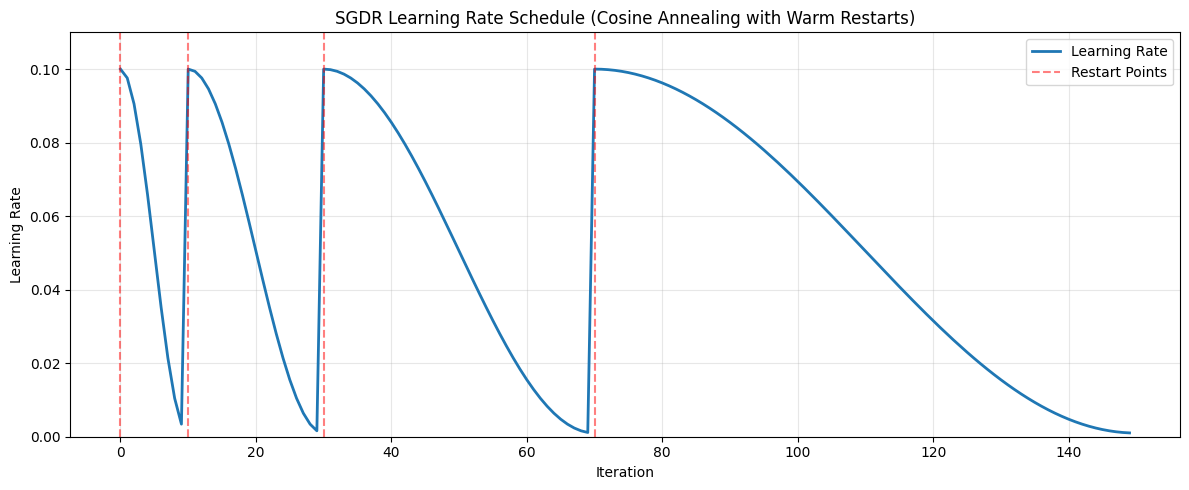

In [16]:
# Visualize SGDR learning rate schedule
fig, ax = plt.subplots(figsize=(12, 5))

# Simulate SGDR schedule
T_0 = 10
T_mult = 2
eta_max = 0.1
eta_min = 0.001
total_iterations = 150

T_cur = 0
T_i = T_0
lrs = []

for i in range(total_iterations):
    lr = eta_min + (eta_max - eta_min) * (1 + np.cos(np.pi * T_cur / T_i)) / 2
    lrs.append(lr)

    T_cur += 1
    if T_cur >= T_i:
        T_cur = 0
        T_i = T_i * T_mult

ax.plot(lrs, linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Learning Rate')
ax.set_title('SGDR Learning Rate Schedule (Cosine Annealing with Warm Restarts)')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, eta_max * 1.1])

# Mark restart points
restart_points = [0]
T_i = T_0
pos = T_0
while pos < total_iterations:
    restart_points.append(pos)
    T_i *= T_mult
    pos += T_i

for rp in restart_points:
    ax.axvline(x=rp, color='red', linestyle='--', alpha=0.5)

ax.legend(['Learning Rate', 'Restart Points'])
plt.tight_layout()
plt.show()

---

## 5. Visualizing Optimizer Trajectories

Let's visualize how different optimizers navigate a loss surface.

In [17]:
def rosenbrock(x, y):
    """Rosenbrock function - a classic optimization test function."""
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(x, y):
    """Gradient of Rosenbrock function."""
    dx = -2 * (1 - x) - 400 * x * (y - x**2)
    dy = 200 * (y - x**2)
    return np.array([dx, dy])

# Optimizer implementations for visualization
def sgd_step(params, grad, lr=0.001):
    return params - lr * grad

def momentum_step(params, grad, velocity, lr=0.001, momentum=0.9):
    velocity = momentum * velocity + grad
    return params - lr * velocity, velocity

def adam_step(params, grad, m, v, t, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    m = beta1 * m + (1 - beta1) * grad
    v = beta2 * v + (1 - beta2) * grad**2
    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)
    return params - lr * m_hat / (np.sqrt(v_hat) + eps), m, v

In [18]:
# Simulate optimizer trajectories
np.random.seed(42)
start_point = np.array([-1.5, 1.5])
n_steps = 500

# SGD trajectory
sgd_path = [start_point.copy()]
params = start_point.copy()
for _ in range(n_steps):
    grad = rosenbrock_grad(*params)
    params = sgd_step(params, grad, lr=0.0001)
    sgd_path.append(params.copy())
sgd_path = np.array(sgd_path)

# Momentum trajectory
momentum_path = [start_point.copy()]
params = start_point.copy()
velocity = np.zeros(2)
for _ in range(n_steps):
    grad = rosenbrock_grad(*params)
    params, velocity = momentum_step(params, grad, velocity, lr=0.0001, momentum=0.9)
    momentum_path.append(params.copy())
momentum_path = np.array(momentum_path)

# Adam trajectory
adam_path = [start_point.copy()]
params = start_point.copy()
m = np.zeros(2)
v = np.zeros(2)
for t in range(1, n_steps + 1):
    grad = rosenbrock_grad(*params)
    params, m, v = adam_step(params, grad, m, v, t, lr=0.01)
    adam_path.append(params.copy())
adam_path = np.array(adam_path)

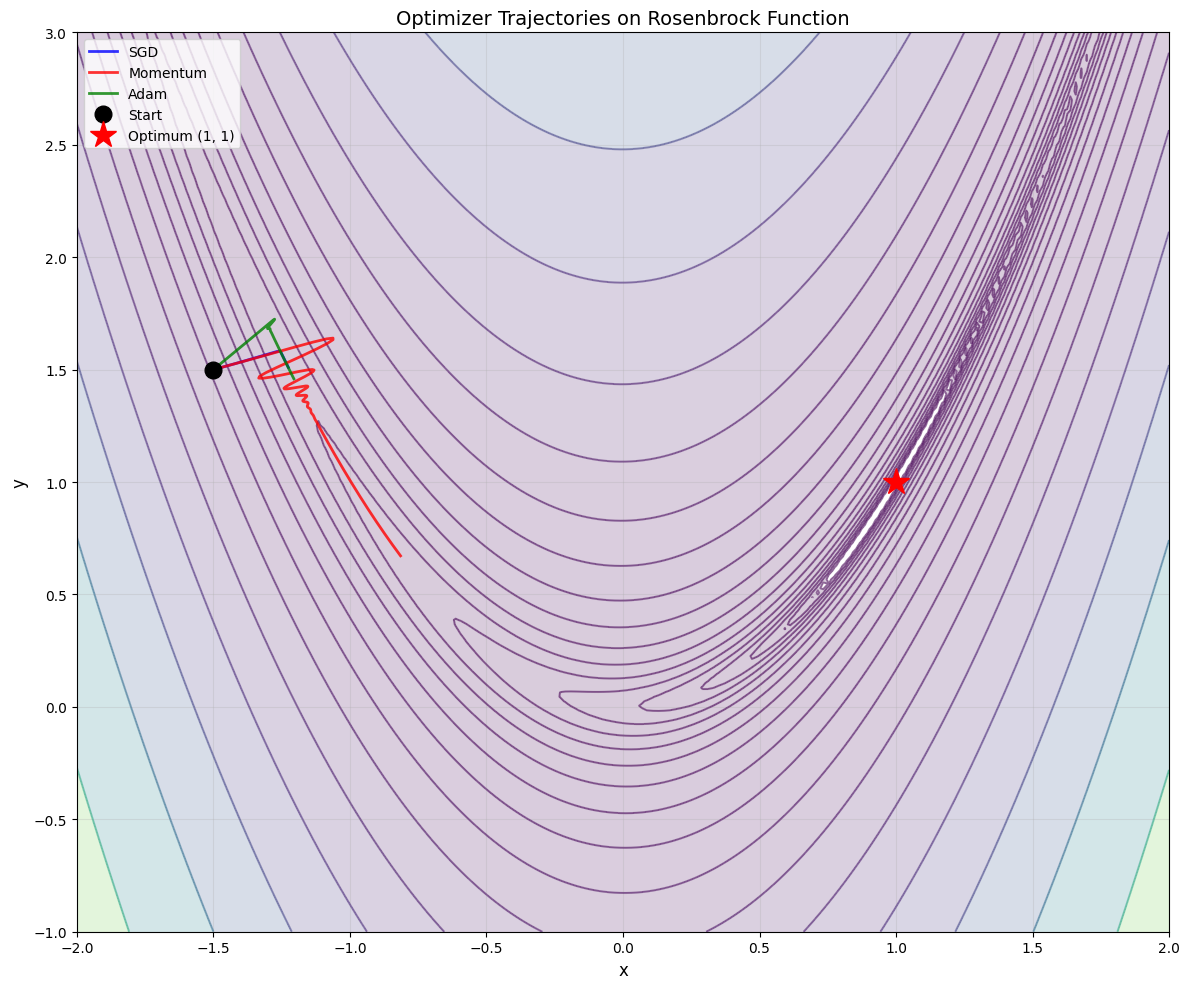

In [19]:
# Visualize trajectories
fig, ax = plt.subplots(figsize=(12, 10))

# Create contour plot of Rosenbrock function
x = np.linspace(-2, 2, 200)
y = np.linspace(-1, 3, 200)
X, Y = np.meshgrid(x, y)
Z = rosenbrock(X, Y)

# Log scale for better visualization
levels = np.logspace(-1, 3.5, 20)
contour = ax.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.5)
ax.contourf(X, Y, Z, levels=levels, cmap='viridis', alpha=0.2)

# Plot trajectories
ax.plot(sgd_path[:, 0], sgd_path[:, 1], 'b-', linewidth=2, label='SGD', alpha=0.8)
ax.plot(momentum_path[:, 0], momentum_path[:, 1], 'r-', linewidth=2, label='Momentum', alpha=0.8)
ax.plot(adam_path[:, 0], adam_path[:, 1], 'g-', linewidth=2, label='Adam', alpha=0.8)

# Mark start and optimal point
ax.plot(*start_point, 'ko', markersize=12, label='Start')
ax.plot(1, 1, 'r*', markersize=20, label='Optimum (1, 1)')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Optimizer Trajectories on Rosenbrock Function', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([-2, 2])
ax.set_ylim([-1, 3])

plt.tight_layout()
plt.show()

In [20]:
# Final positions
print("Final positions after 500 steps:")
print(f"SGD:      ({sgd_path[-1, 0]:.4f}, {sgd_path[-1, 1]:.4f}), Loss: {rosenbrock(*sgd_path[-1]):.4f}")
print(f"Momentum: ({momentum_path[-1, 0]:.4f}, {momentum_path[-1, 1]:.4f}), Loss: {rosenbrock(*momentum_path[-1]):.4f}")
print(f"Adam:     ({adam_path[-1, 0]:.4f}, {adam_path[-1, 1]:.4f}), Loss: {rosenbrock(*adam_path[-1]):.4f}")
print(f"\nOptimum:  (1.0000, 1.0000), Loss: 0.0000")

Final positions after 500 steps:
SGD:      (-1.2257, 1.5101), Loss: 4.9597
Momentum: (-0.8147, 0.6718), Loss: 3.2996
Adam:     (-1.2054, 1.4591), Loss: 4.8676

Optimum:  (1.0000, 1.0000), Loss: 0.0000


---

## 6. Summary and Best Practices

In [21]:
import pandas as pd

# Summary table
summary_data = {
    'Optimizer': ['SGD', 'Momentum', 'Adam', 'SGDR'],
    'Key Feature': ['Simple gradient descent', 'Accumulated gradients',
                    'Adaptive learning rates', 'Warm restarts'],
    'Pros': ['Simple, few hyperparameters', 'Faster convergence',
             'Works well out of box', 'Escapes local minima'],
    'Cons': ['Slow convergence', 'May overshoot',
             'More memory', 'More hyperparameters'],
    'Best For': ['Simple problems', 'General training',
                 'Default choice', 'Fine-tuning']
}

df = pd.DataFrame(summary_data)
print("Optimizer Comparison:")
print("=" * 100)
print(df.to_string(index=False))

Optimizer Comparison:
Optimizer             Key Feature                        Pros                 Cons         Best For
      SGD Simple gradient descent Simple, few hyperparameters     Slow convergence  Simple problems
 Momentum   Accumulated gradients          Faster convergence        May overshoot General training
     Adam Adaptive learning rates       Works well out of box          More memory   Default choice
     SGDR           Warm restarts        Escapes local minima More hyperparameters      Fine-tuning


### Best Practices for Custom Optimizers

1. **State Management**
   - Initialize state variables (velocity, moments) in `build()`
   - Use proper variable scoping

2. **Numerical Stability**
   - Add small epsilon values in divisions
   - Use proper dtype casting

3. **Learning Rate**
   - Support learning rate schedules
   - Allow for warm-up periods

4. **Testing**
   - Compare with built-in implementations
   - Test on simple functions (Rosenbrock, Rastrigin)
   - Verify gradient updates

In [22]:
print("\nNotebook completed successfully!")
print("="*50)
print("Key takeaways:")
print("1. Optimizers update parameters based on gradients")
print("2. Momentum accumulates past gradients for faster convergence")
print("3. Adam combines momentum with adaptive learning rates")
print("4. SGDR uses warm restarts to escape local minima")
print("5. Both TensorFlow and PyTorch support custom optimizer creation")


Notebook completed successfully!
Key takeaways:
1. Optimizers update parameters based on gradients
2. Momentum accumulates past gradients for faster convergence
3. Adam combines momentum with adaptive learning rates
4. SGDR uses warm restarts to escape local minima
5. Both TensorFlow and PyTorch support custom optimizer creation
